**Q3. Feature Engineering and Regression Pipeline**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

**1. Date Feature Engineering**

In [17]:
# Read the CSV file into a DataFrame
df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert transaction_date to datetime for feature extraction
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract year, month, day_of_week
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end binary feature (1 if day of month >= 25, else 0)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Set pandas to display all columns in a single row
pd.set_option('display.expand_frame_repr', False)

# Display the first five rows to confirm new columns
print("\nFirst 5 rows with Engineered Features:\n", df.head())



First 5 rows with Engineered Features:
   transaction_date  store_id store_size location_type  promotion_type  is_weekend  is_festival  competition_density  items_sold  year  month  day_of_week  is_month_end
0       2022-01-01        28      small    semi-urban       free_gift           1            0                    5         224  2022      1            5             0
1       2022-01-01         5     medium    semi-urban       free_gift           1            1                    1         348  2022      1            5             0
2       2022-01-02        13      small    semi-urban  loyalty_points           1            0                    6         249  2022      1            6             0
3       2022-01-02        17      small         urban       free_gift           1            0                    7         259  2022      1            6             0
4       2022-01-03        50     medium    semi-urban            bogo           0            0                    3    

**2. Temporal Train-Test Split**

In [18]:
# Sort the data by transaction_date 
df = df.sort_values('transaction_date').reset_index(drop=True)

# Temporal split: Use the most recent 20% of records for test, remaining 80% for training
split_point = int(len(df)*0.8)
train_df = df.iloc[:split_point]
test_df = df.iloc[split_point:]

# Define features and target 
X_train = train_df.drop(columns=['items_sold', 'transaction_date', 'store_id'])
y_train = train_df['items_sold']
X_test = test_df.drop(columns=['items_sold', 'transaction_date', 'store_id'])
y_test = test_df['items_sold']

print("Data split into training and testing sets successfully.")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Data split into training and testing sets successfully.
Training set shape: (960, 10)
Testing set shape: (240, 10)


### Why a Random Split is Inappropriate for Time-Ordered Data

In this dataset, transactions are recorded chronologically, meaning the order of the data carries real meaning. A random split would scatter records from different time periods randomly across training and test sets, allowing the model to train on future data and evaluate on past data.

This creates **data leakage** — the model effectively "sees the future" during training, leading to performance scores that look better than they actually are in practice.

A **temporal split** preserves the natural time order by training on earlier records and testing on the most recent 20%. This mirrors how the model would realistically be deployed — learning from historical sales to predict what comes next — giving a much more honest picture of how well it actually performs.

**3. Preprocessing Pipeline**

In [19]:
# Define categorical and numerical features
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = [col for col in X_train.columns if col not in categorical_features]

# Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("Preprocessing Pipeline using ColumnTransformer built successfully.")


Preprocessing Pipeline using ColumnTransformer built successfully.


The `ColumnTransformer` defines the preprocessing steps for both numerical and categorical features. The full `Pipeline` — combining this preprocessor with each regression model — is assembled and fitted in Task 4, keeping the model training and preprocessing steps together in one reproducible object.

**4. Model Training and Evaluation**


--- Linear Regression Results ---
RMSE: 27.1252
MAE: 21.0715


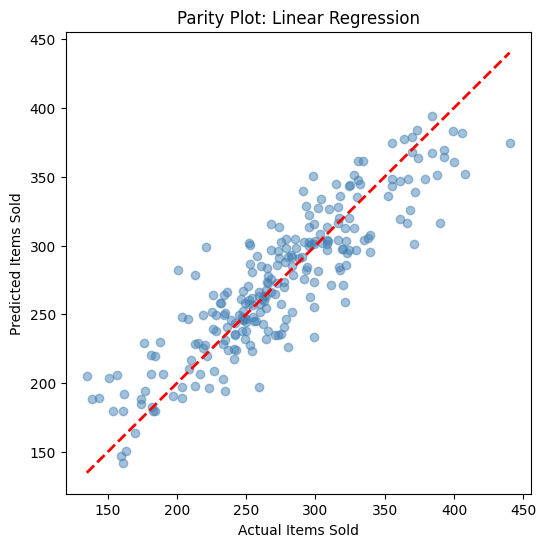


--- Random Forest Results ---
RMSE: 31.1194
MAE: 24.9959


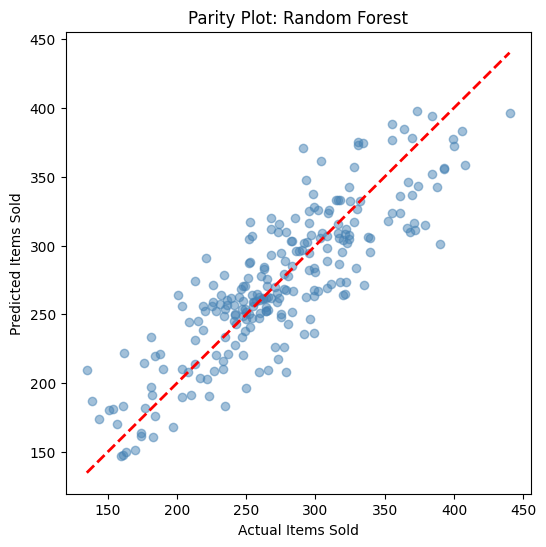


Top 5 Most Influential Features (Random Forest):
                Feature  Importance
1           is_festival    0.173557
17     store_size_small    0.168355
14  location_type_urban    0.108331
5           day_of_week    0.095854
2   competition_density    0.063912


In [20]:
# Helper function to fit and evaluate models
def evaluate_regression_model(model, name):
    # Create the full pipeline
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Fit only on the training set
    full_pipeline.fit(X_train, y_train)

    # Predict on the test set
    y_pred = full_pipeline.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\n--- {name} Results ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

    # Parity Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.title(f'Parity Plot: {name}')
    plt.show()

    return full_pipeline

# Train Linear Regression
lr_pipe = evaluate_regression_model(LinearRegression(), "Linear Regression")

# Train Random Forest Regressor
rf_pipe = evaluate_regression_model(RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest")

# Feature Importances from Random Forest
rf_model = rf_pipe.named_steps['regressor']
cat_encoder = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']
all_feature_names = numerical_features + list(cat_encoder.get_feature_names_out(categorical_features))

feat_importance = pd. DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Influential Features (Random Forest):")
print(feat_importance.head(5))